# Couzin-only robustness and imitation tests

This notebook is deliberately isolated from the biological analysis. It neither loads nor modifies biological trajectories, results, or plots. It tests why the synthetic Couzin demonstrations and their GAIL imitation diverge, while retaining the visual grammar of the final paper figures.

The analyses are diagnostic rather than a search for visually convenient overlap. Each condition is declared before execution, uses independent Couzin seeds, and is assessed by mean gaps, interquartile-range overlap, and fixed metric-specific tolerances.

In [1]:
from dataclasses import replace
from pathlib import Path
import importlib, os, sys
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display, Markdown

ANALYSIS_DIR = Path.cwd().resolve()
if ANALYSIS_DIR.name != 'Paper Analysis':
    ANALYSIS_DIR = ANALYSIS_DIR / 'Paper Analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))
import couzin_test as ct
ct = importlib.reload(ct)

OUTPUT_DIR = ANALYSIS_DIR / os.getenv('COUZIN_TEST_OUTPUT_DIR', 'couzin_test_outputs')
SAVE_ARTIFACTS = os.getenv('COUZIN_TEST_SAVE_ARTIFACTS', '0') == '1'
if SAVE_ARTIFACTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ROLLOUT_SEEDS = tuple(int(x) for x in os.getenv('COUZIN_TEST_SEEDS', '2027').split(','))
N_ROLLOUTS = int(os.getenv('COUZIN_TEST_ROLLOUTS', '6'))
INCLUDE_LONG_BASELINE = os.getenv('COUZIN_TEST_LONG_BASELINE', '1') == '1'
REPAIR_STEPS = int(os.getenv('COUZIN_TEST_REPAIR_STEPS', '500'))
LARGE_APPROACH_TARGET = int(os.getenv('COUZIN_TEST_APPROACH_WINDOWS', '40'))
LARGE_APPROACH_MIN = int(os.getenv('COUZIN_TEST_APPROACH_MIN', '30'))
LARGE_APPROACH_MAX_ROLLOUTS = int(os.getenv('COUZIN_TEST_APPROACH_MAX_ROLLOUTS', '120'))
LARGE_APPROACH_BATCH = int(os.getenv('COUZIN_TEST_APPROACH_BATCH', '10'))
assert N_ROLLOUTS >= 2 and REPAIR_STEPS >= 1
assert 1 <= LARGE_APPROACH_MIN <= LARGE_APPROACH_TARGET <= LARGE_APPROACH_MAX_ROLLOUTS
display({'output_dir': str(OUTPUT_DIR), 'seeds': ROLLOUT_SEEDS,
         'rollouts_per_seed': N_ROLLOUTS, 'repair_steps': REPAIR_STEPS,
         'large_approach_target': LARGE_APPROACH_TARGET,
         'large_approach_minimum': LARGE_APPROACH_MIN,
         'large_approach_max_rollouts': LARGE_APPROACH_MAX_ROLLOUTS,
         'long_baseline': INCLUDE_LONG_BASELINE, 'save_artifacts': SAVE_ARTIFACTS})

{'output_dir': 'C:\\Users\\janni\\OneDrive\\Dokumente\\Privat\\Bildung\\M. Sc. Social and Economic Data Science\\Thesis Paper\\ICRA2027-PredatorPreyGAIL\\Paper Analysis\\couzin_test_outputs',
 'seeds': (2027,),
 'rollouts_per_seed': 4,
 'repair_steps': 300,
 'large_approach_target': 40,
 'large_approach_minimum': 30,
 'large_approach_max_rollouts': 120,
 'long_baseline': True,
 'save_artifacts': False}

## Analysis 0 — Provenance and parity audit

Before changing stochasticity, this audit records factors that can create apparent model failure by themselves: different integration steps and Couzin parameters, a tenfold evaluation-horizon extension, incompatible semantics in the final input feature, and independently selected predator/prey checkpoints. These findings motivate the controlled variants below.

In [2]:
display(ct.provenance_audit())

,component,training,former_evaluation,consequence,training_expert
0,Integration step,0.25,0.5,Different displacement and maximum turn per step,NaN
1,Couzin alpha,0.01,0.1,Different balance of threat avoidance and soci...,NaN
2,Policy horizon,100 steps,"1,000 steps",Tenfold long-horizon distribution shift,NaN
3,Last predator feature,policy rollout: active=1,active=1,Expert and generated discriminator inputs use ...,neighbor heading
4,Last prey feature,policy rollout: active=1,active=1,Same semantic mismatch for the prey discriminator,neighbor heading
5,Checkpoint pairing,role-wise best on N=32,independently selected files,Predator and prey may come from different gene...,NaN


## Analysis 1 — Environment, horizon, checkpoint, and feature variants

The former paper baseline evaluates 1,000 steps at `dt=0.5` and `alpha=0.1`. The training-matched variants instead use `dt=0.25`, `alpha=0.01`, 100 steps, and the original wall order. Additional variants test deterministic actions, predator/prey states saved at the same final generation, the joint EMA pair, and the neighbor-heading feature found in the expert tensors. The heading variant is only a mismatch diagnostic: a valid correction requires retraining with one common schema.

,variant,variant_label,mean_scaled_gap,median_scaled_gap,comparisons,iqr_overlaps
0,training_matched,Training-matched evaluation,0.208653,0.164306,12,2
1,training_matched_deterministic,"Training-matched, deterministic",0.210432,0.156574,12,2
2,joint_last,Joint final-generation pair,0.218487,0.154187,12,2
3,heading_schema_diagnostic,Heading-feature diagnostic,0.219229,0.172130,12,2
4,joint_ema,Joint final-generation EMA pair,0.222940,0.173742,12,1
5,current_paper,Current paper baseline,0.379044,0.281452,12,0


### Current paper baseline

Reproduces the former final-analysis setup: evaluation at dt=0.5, Couzin alpha=0.1, 1,000 steps, stochastic policies, and corrected post-step wall reflection.

,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
0,16,Normalized predator distance,0.0497,0.1052,0.0555,0.0
1,16,Pursuit alignment,0.8996,0.0717,0.8279,0.0
2,16,Escape alignment,0.3145,-0.0177,0.3322,0.0
3,16,Prey reorientation R,-0.0409,-0.0691,0.0283,0.0
4,16,Degree of Swarm (DoS),0.0631,0.1002,0.0371,0.0
5,16,Degree of Alignment (DoA),0.8456,0.6419,0.2036,0.0
6,32,Normalized predator distance,0.0568,0.0681,0.0114,0.0
7,32,Pursuit alignment,0.8679,-0.0025,0.8704,0.0
8,32,Escape alignment,0.2586,-0.0217,0.2804,0.0
9,32,Prey reorientation R,-0.0426,-0.0697,0.0271,0.0


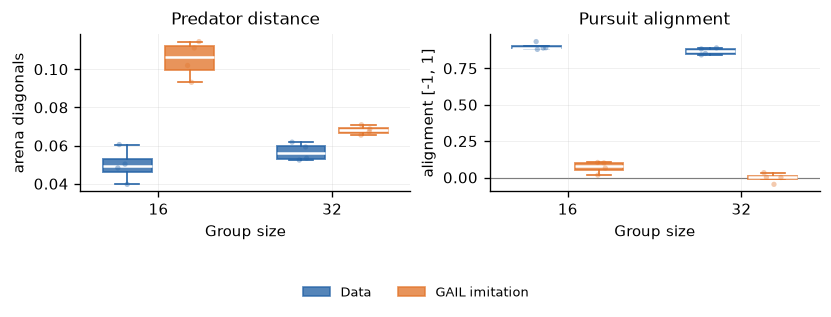

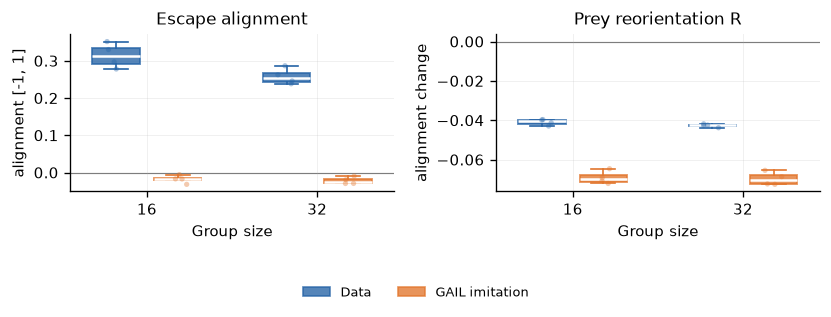

**Couzin expert DoS/DoA for the trajectories used above.**

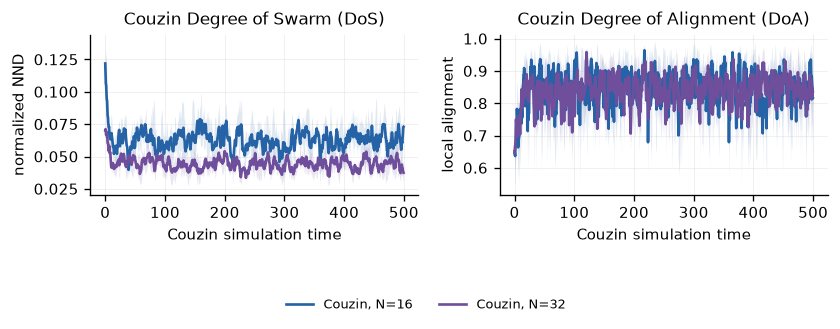

### Training-matched evaluation

Uses the environment recorded in the Couzin training notebook: dt=0.25, alpha=0.01, a 100-step policy horizon, and legacy wall order.

,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
12,16,Normalized predator distance,0.1053,0.1075,0.0022,0.012
13,16,Pursuit alignment,0.6593,0.0772,0.5821,0.000
14,16,Escape alignment,0.1733,0.0222,0.1511,0.000
15,16,Prey reorientation R,-0.0188,-0.0365,0.0178,0.000
16,16,Degree of Swarm (DoS),0.0773,0.0991,0.0217,0.000
17,16,Degree of Alignment (DoA),0.7347,0.6445,0.0903,0.000
18,32,Normalized predator distance,0.0762,0.0677,0.0085,0.007
19,32,Pursuit alignment,0.6657,0.0121,0.6536,0.000
20,32,Escape alignment,0.2135,0.0290,0.1846,0.000
21,32,Prey reorientation R,-0.0192,-0.0380,0.0187,0.000


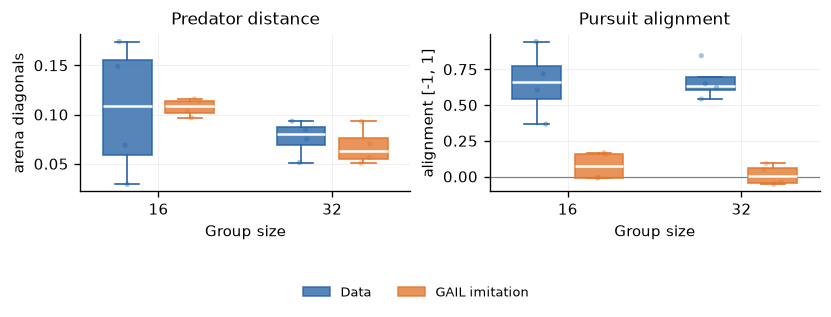

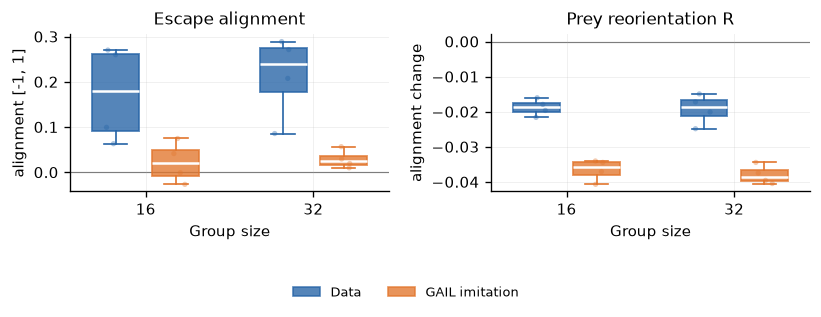

**Couzin expert DoS/DoA for the trajectories used above.**

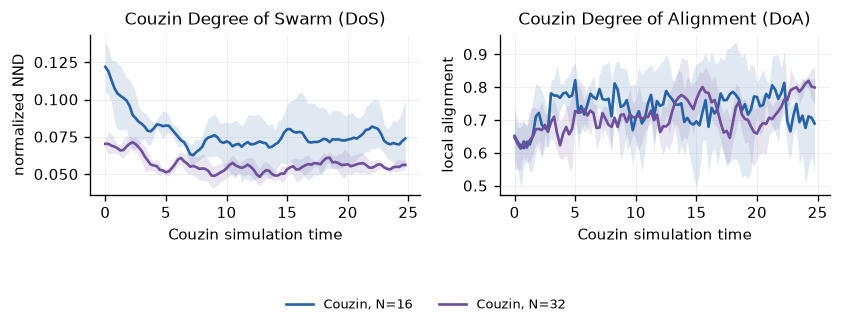

### Training-matched, deterministic

Removes policy sampling at evaluation to test whether action sampling is responsible for excess imitation variability.

,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
24,16,Normalized predator distance,0.1053,0.1087,0.0034,0.014
25,16,Pursuit alignment,0.6593,0.0810,0.5783,0.000
26,16,Escape alignment,0.1733,0.0334,0.1399,0.000
27,16,Prey reorientation R,-0.0188,-0.0366,0.0178,0.000
28,16,Degree of Swarm (DoS),0.0773,0.1015,0.0242,0.000
29,16,Degree of Alignment (DoA),0.7347,0.6382,0.0965,0.000
30,32,Normalized predator distance,0.0762,0.0651,0.0111,0.001
31,32,Pursuit alignment,0.6657,0.0372,0.6285,0.000
32,32,Escape alignment,0.2135,0.0403,0.1733,0.000
33,32,Prey reorientation R,-0.0192,-0.0376,0.0184,0.000


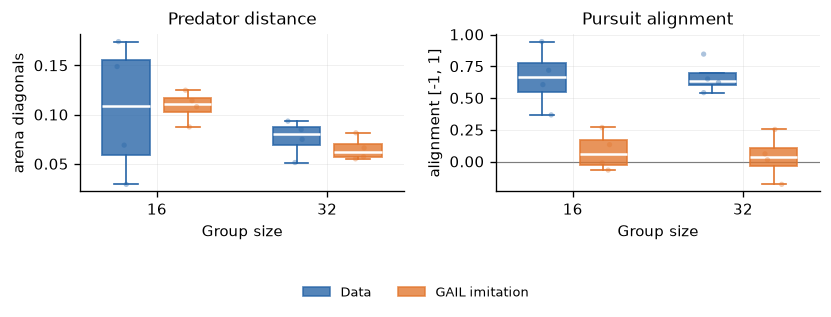

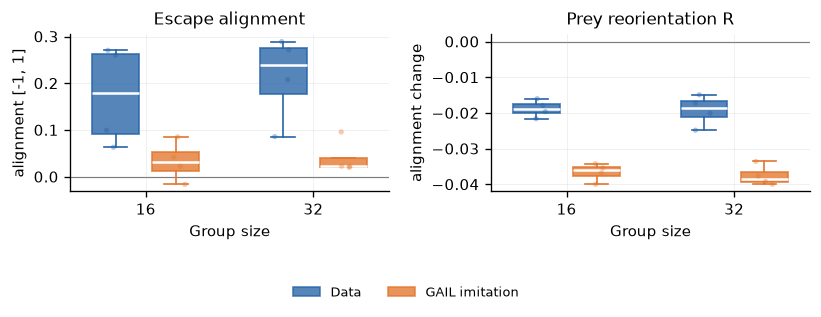

**Couzin expert DoS/DoA for the trajectories used above.**

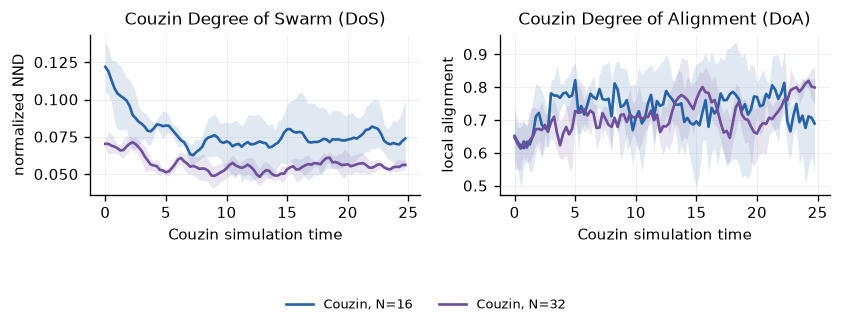

### Joint final-generation pair

Uses predator and prey states from the same final training generation instead of independently selected best policies.

,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
36,16,Normalized predator distance,0.1053,0.1020,0.0034,0.0222
37,16,Pursuit alignment,0.6593,0.1185,0.5407,0.0000
38,16,Escape alignment,0.1733,0.0362,0.1371,0.0000
39,16,Prey reorientation R,-0.0188,-0.0365,0.0177,0.0000
40,16,Degree of Swarm (DoS),0.0773,0.1031,0.0258,0.0000
41,16,Degree of Alignment (DoA),0.7347,0.6333,0.1014,0.0000
42,32,Normalized predator distance,0.0762,0.0628,0.0134,0.0014
43,32,Pursuit alignment,0.6657,-0.0102,0.6759,0.0000
44,32,Escape alignment,0.2135,0.0423,0.1712,0.0000
45,32,Prey reorientation R,-0.0192,-0.0383,0.0190,0.0000


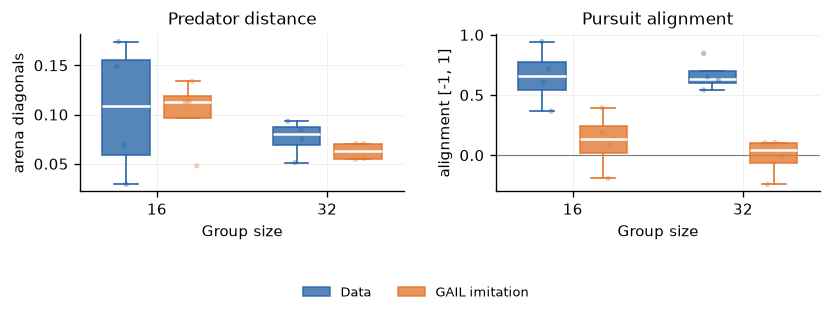

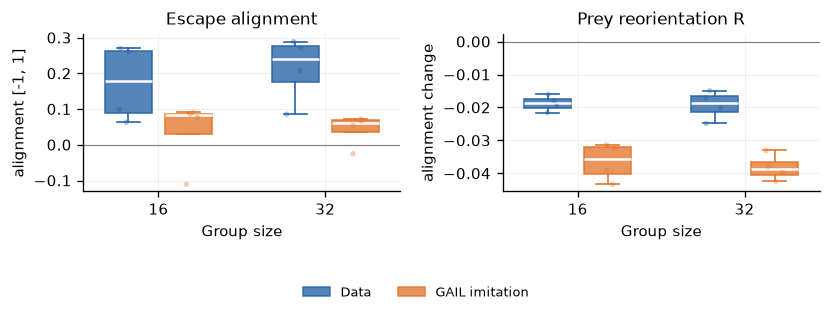

**Couzin expert DoS/DoA for the trajectories used above.**

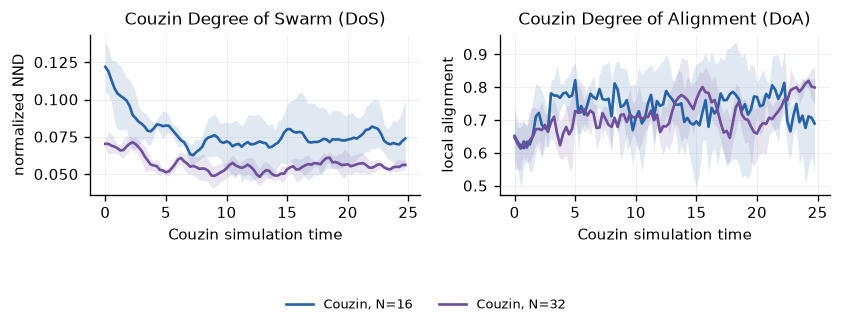

### Joint final-generation EMA pair

Uses the coexisting EMA predator/prey pair from the final generation, preserving co-adaptation between roles.

,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
48,16,Normalized predator distance,0.1053,0.1002,0.0051,0.0333
49,16,Pursuit alignment,0.6593,0.0003,0.6589,0.0000
50,16,Escape alignment,0.1733,0.0088,0.1645,0.0000
51,16,Prey reorientation R,-0.0188,-0.0371,0.0183,0.0000
52,16,Degree of Swarm (DoS),0.0773,0.1002,0.0228,0.0000
53,16,Degree of Alignment (DoA),0.7347,0.6234,0.1113,0.0000
54,32,Normalized predator distance,0.0762,0.0644,0.0118,0.0000
55,32,Pursuit alignment,0.6657,0.0628,0.6028,0.0000
56,32,Escape alignment,0.2135,0.0249,0.1887,0.0000
57,32,Prey reorientation R,-0.0192,-0.0377,0.0184,0.0000


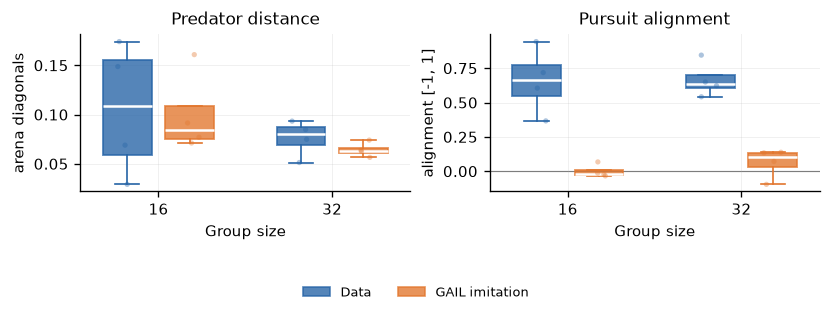

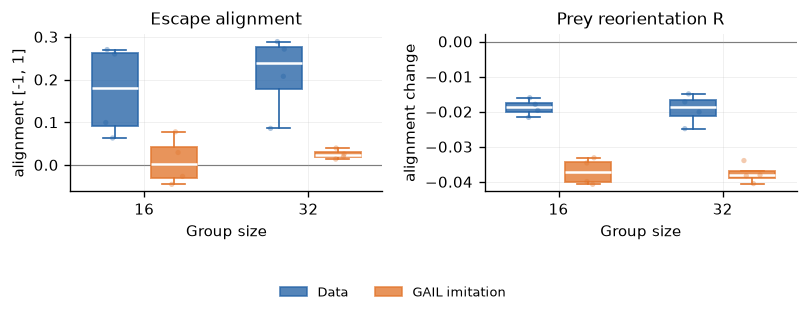

**Couzin expert DoS/DoA for the trajectories used above.**

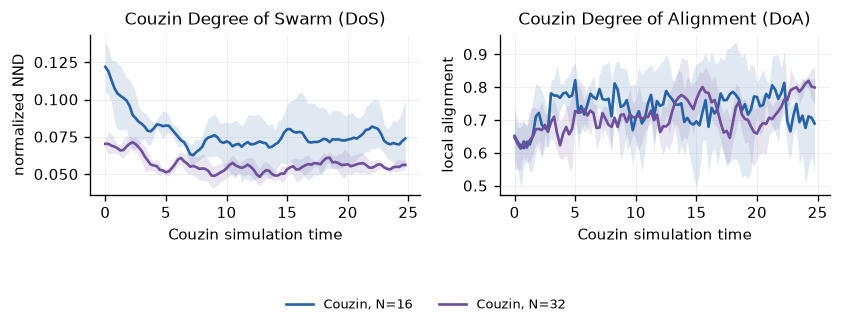

### Heading-feature diagnostic

Feeds neighbor heading in the last feature slot. This is a diagnostic for the discovered expert/rollout feature mismatch, not a valid replacement for retraining.

,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
60,16,Normalized predator distance,0.1053,0.1067,0.0013,0.0112
61,16,Pursuit alignment,0.6593,0.0112,0.6481,0.0000
62,16,Escape alignment,0.1733,0.0131,0.1602,0.0000
63,16,Prey reorientation R,-0.0188,-0.0372,0.0184,0.0000
64,16,Degree of Swarm (DoS),0.0773,0.0995,0.0222,0.0000
65,16,Degree of Alignment (DoA),0.7347,0.6431,0.0916,0.0000
66,32,Normalized predator distance,0.0762,0.0677,0.0085,0.0071
67,32,Pursuit alignment,0.6657,-0.0292,0.6949,0.0000
68,32,Escape alignment,0.2135,0.0226,0.1909,0.0000
69,32,Prey reorientation R,-0.0192,-0.0380,0.0188,0.0000


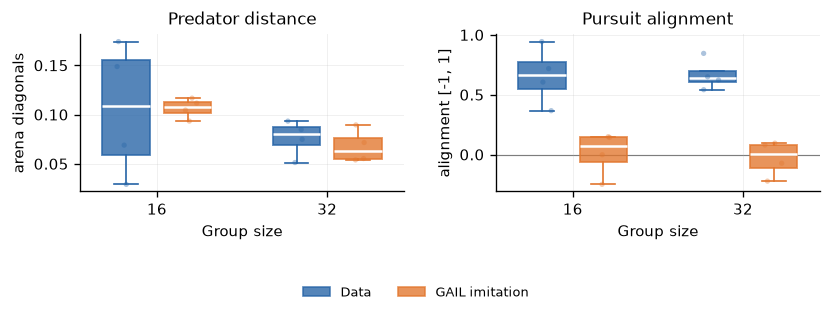

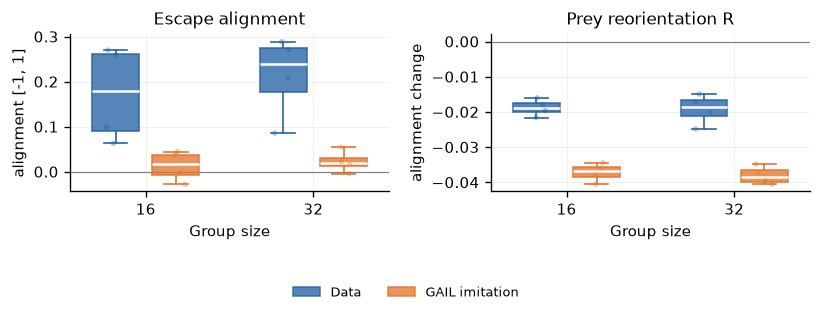

**Couzin expert DoS/DoA for the trajectories used above.**

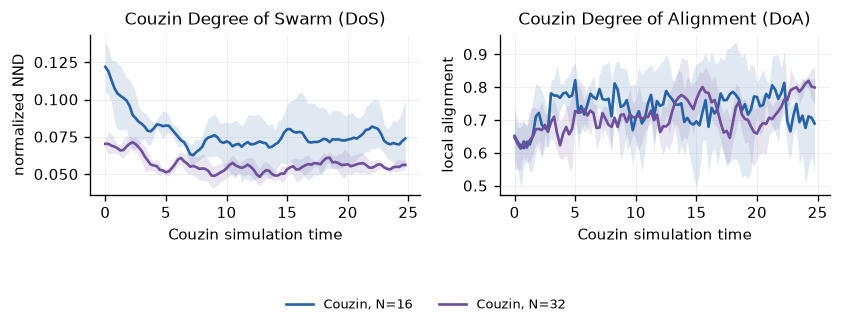

In [3]:
screen_specs = ct.default_screening_variants()
if INCLUDE_LONG_BASELINE:
    screen_specs = [ct.CURRENT_PAPER, *screen_specs]
screen_results, screen_details, screen_ranking = ct.evaluate_variants(
    screen_specs, rollout_seeds=ROLLOUT_SEEDS, n_rollouts_per_seed=N_ROLLOUTS)
display(screen_ranking)
for spec in screen_specs:
    display(Markdown(f'### {spec.label}\n\n{spec.explanation}'))
    display(screen_details.loc[screen_details.variant == spec.name,
        ['n_prey', 'metric_label', 'expert_mean', 'imitation_mean',
         'absolute_gap', 'iqr_overlap']].round(4))
    for category in ('Predator', 'Prey'):
        fig = ct.plot_behavior_boxplots(screen_results[spec.name], category)
        display(fig); plt.close(fig)
    display(Markdown('**Couzin expert DoS/DoA for the trajectories used above.**'))
    fig = ct.plot_expert_collective_timelines(screen_results[spec.name])
    display(fig); plt.close(fig)
    if SAVE_ARTIFACTS:
        ct.save_variant_artifacts(screen_results[spec.name], OUTPUT_DIR)

## Analysis 2 — Structured movement-noise sensitivity

A deterministic Couzin controller produces little between-rollout variability. Here, zero-mean Gaussian turn noise of 1°, 2.5°, or 5° per transition is inserted into both expert and policy dynamics under the training-matched environment. This is process noise rather than post-hoc plot jitter. Applying it symmetrically prevents the reference distribution from being widened solely to make the imitation look better. The no-noise training-matched condition from Analysis 1 is the comparator.

,variant,variant_label,mean_scaled_gap,iqr_overlaps
0,training_matched,Training-matched evaluation,0.208653,2
1,turn_noise_1p0deg,Turn noise 1°/step,0.230344,2
2,turn_noise_5p0deg,Turn noise 5°/step,0.238308,2
3,turn_noise_2p5deg,Turn noise 2.5°/step,0.244513,2


### Turn noise 1°/step

Adds zero-mean Gaussian heading noise with SD 1° per transition to both Couzin and policy dynamics.

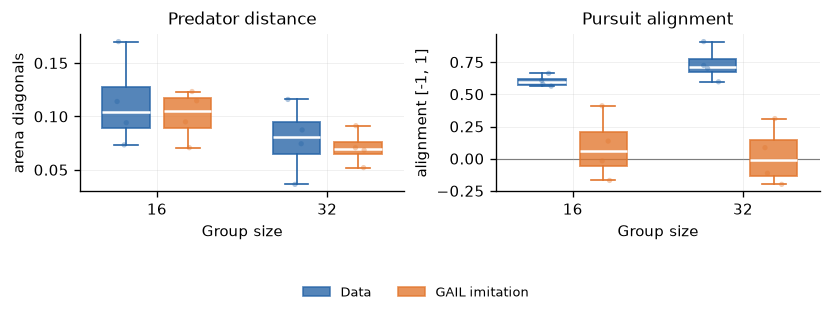

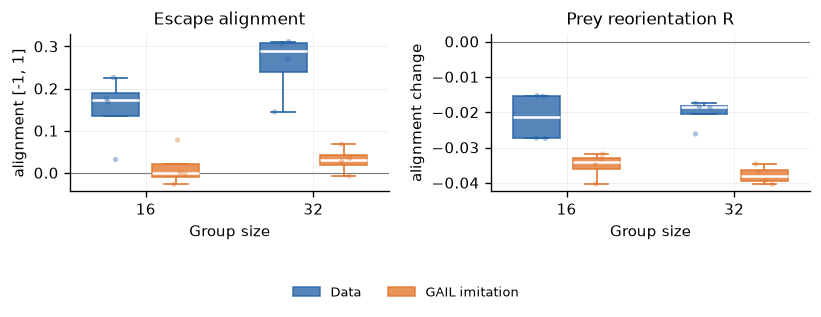

**Couzin expert DoS/DoA for the trajectories used above.**

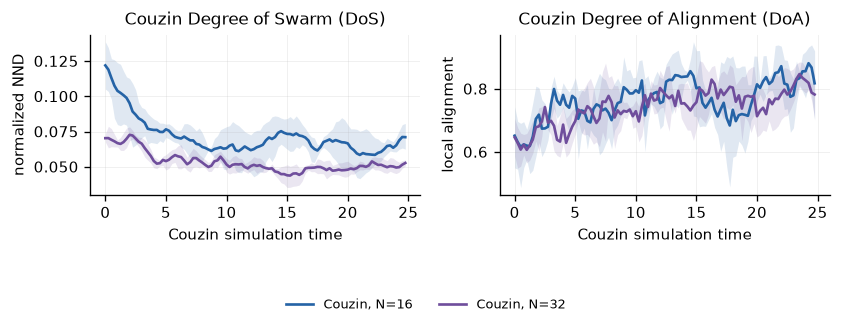

### Turn noise 2.5°/step

Adds zero-mean Gaussian heading noise with SD 2.5° per transition to both Couzin and policy dynamics.

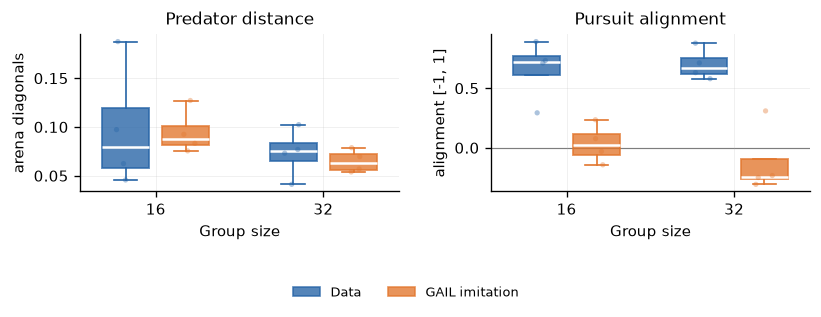

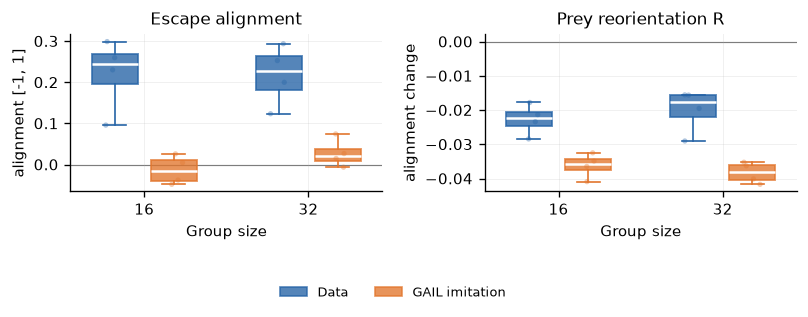

**Couzin expert DoS/DoA for the trajectories used above.**

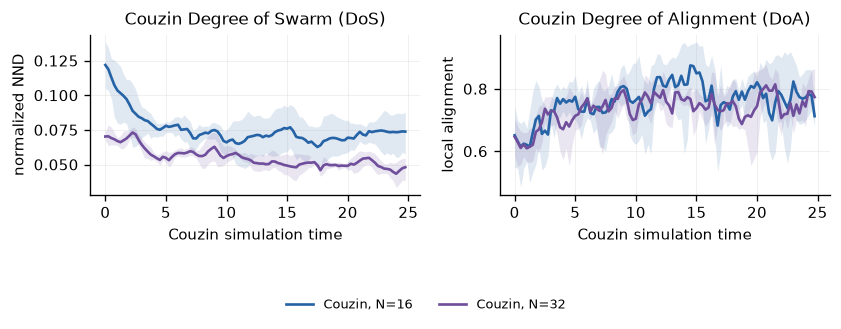

### Turn noise 5°/step

Adds zero-mean Gaussian heading noise with SD 5° per transition to both Couzin and policy dynamics.

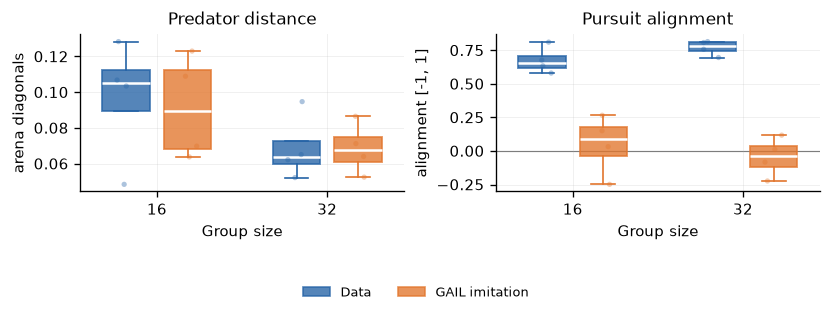

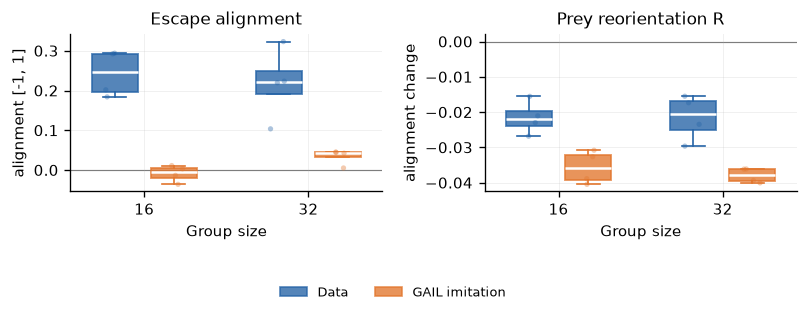

**Couzin expert DoS/DoA for the trajectories used above.**

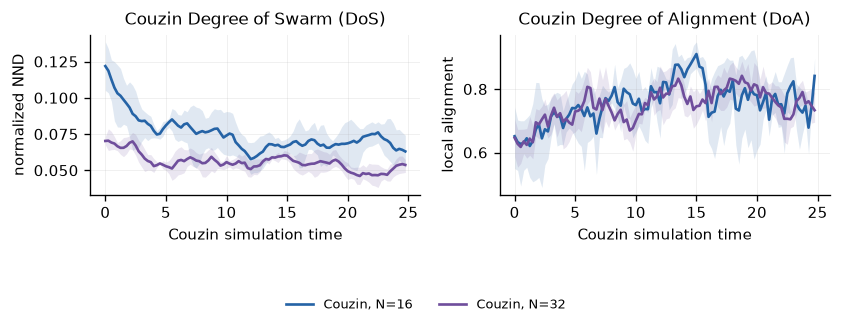

In [4]:
noise_specs = ct.noise_variants()[1:]
noise_results, noise_details, noise_ranking = ct.evaluate_variants(
    noise_specs, rollout_seeds=ROLLOUT_SEEDS, n_rollouts_per_seed=N_ROLLOUTS)
noise_comparison = pd.concat([
    screen_details.loc[screen_details.variant == 'training_matched'], noise_details
], ignore_index=True)
display(noise_comparison.groupby(['variant', 'variant_label'], as_index=False).agg(
    mean_scaled_gap=('scaled_absolute_gap', 'mean'),
    iqr_overlaps=('iqr_overlap', lambda x: int((x > 0).sum()))
).sort_values('mean_scaled_gap', ignore_index=True))
for spec in noise_specs:
    display(Markdown(f'### {spec.label}\n\n{spec.explanation}'))
    for category in ('Predator', 'Prey'):
        fig = ct.plot_behavior_boxplots(noise_results[spec.name], category)
        display(fig); plt.close(fig)
    display(Markdown('**Couzin expert DoS/DoA for the trajectories used above.**'))
    fig = ct.plot_expert_collective_timelines(noise_results[spec.name])
    display(fig); plt.close(fig)
    if SAVE_ARTIFACTS:
        ct.save_variant_artifacts(noise_results[spec.name], OUTPUT_DIR)

## Analysis 3 — Matched approach-window variability

Whole-episode averages over 1,000 steps suppress scenario variability and emphasize accumulated rollout drift. This analysis detects approaches using a fixed distance threshold, positive closing motion, and persistent nearest target. It then compares expert and policy from exactly the same initial state in fixed 20-, 40-, and 80-step windows. At most one window is retained per independent source rollout. Shorter windows are expected to test local attack behavior; the horizon sensitivity reveals whether any agreement survives beyond initialization.

### 20-step matched approach windows

Only objectively detected expert approaches define the starts; all matched policy failures remain in the analysis.

,windows,mean_onset_distance
n_prey,,
16,3,0.083828
32,3,0.130597


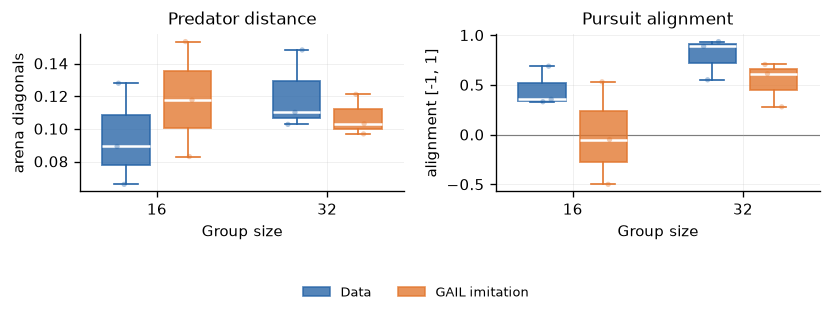

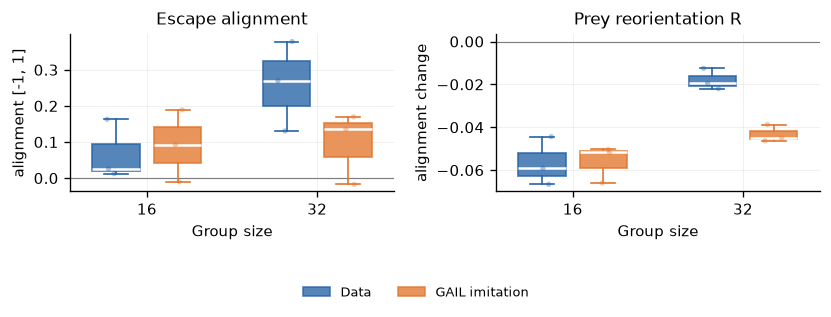

**Couzin expert DoS/DoA for these approach windows.**

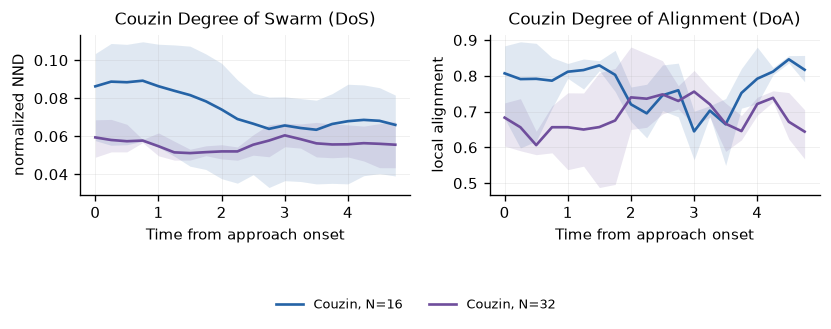

### 40-step matched approach windows

Only objectively detected expert approaches define the starts; all matched policy failures remain in the analysis.

,windows,mean_onset_distance
n_prey,,
16,3,0.083828
32,3,0.130597


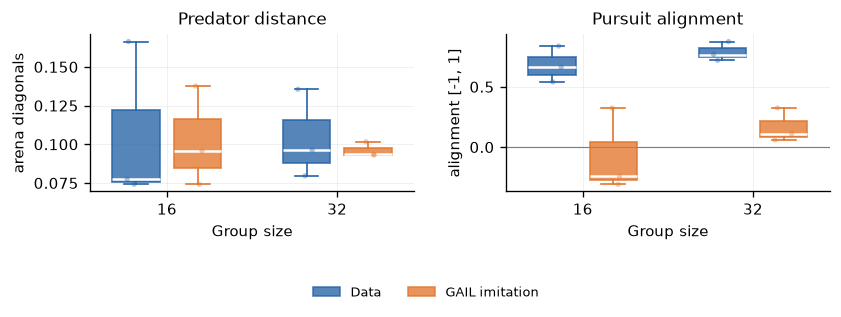

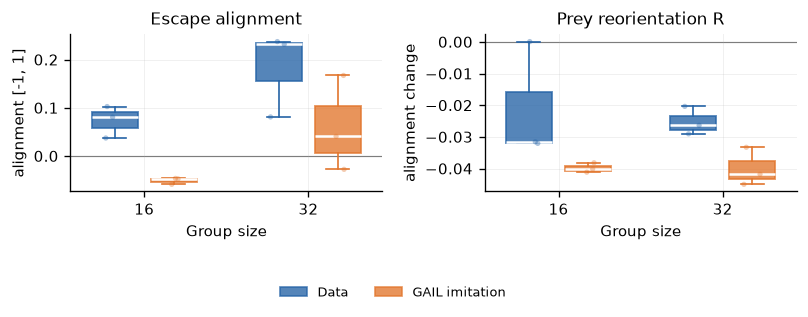

**Couzin expert DoS/DoA for these approach windows.**

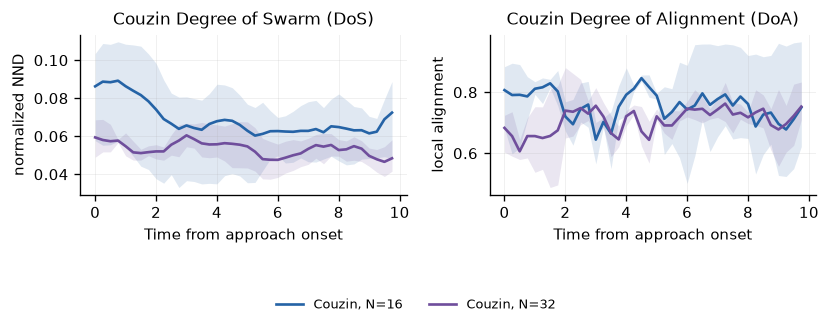

### 80-step matched approach windows

Only objectively detected expert approaches define the starts; all matched policy failures remain in the analysis.

,windows,mean_onset_distance
n_prey,,
16,3,0.083828
32,3,0.130597


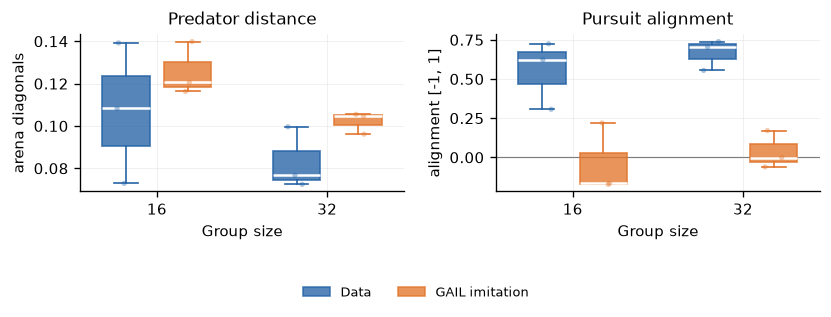

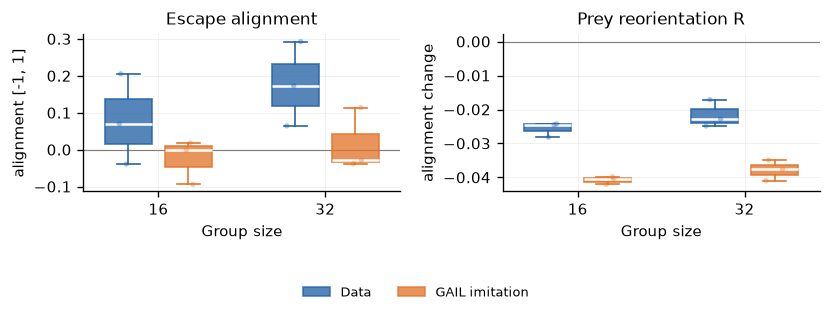

**Couzin expert DoS/DoA for these approach windows.**

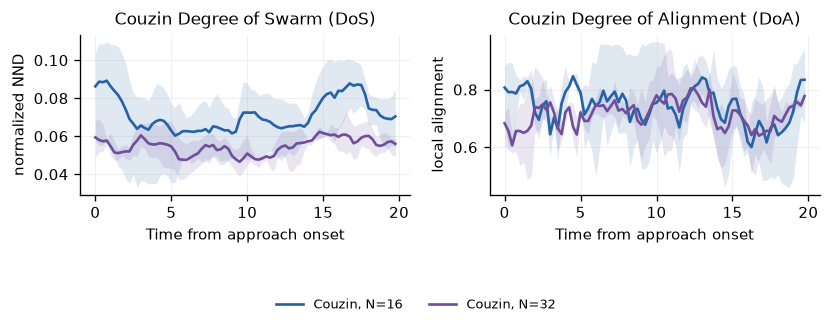

In [5]:
approach_results, approach_rows = {}, []
for window_steps in (20, 40, 80):
    display(Markdown(f'### {window_steps}-step matched approach windows\n\n'
                     'Only objectively detected expert approaches define the starts; all matched policy failures remain in the analysis.'))
    result = ct.evaluate_approach_variant(
        ct.TRAINING_MATCHED, rollout_seeds=ROLLOUT_SEEDS,
        n_source_rollouts_per_seed=N_ROLLOUTS, source_steps=300,
        window_steps=window_steps, pre_steps=5)
    approach_results[result['spec'].name] = result
    approach_rows.extend(ct.result_rows(result))
    display(pd.concat([group['window_audit'].assign(n_prey=n)
                       for n, group in result['groups'].items()], ignore_index=True)
            .groupby('n_prey').agg(windows=('window_id', 'size'),
                                    mean_onset_distance=('approach_distance', 'mean')))
    for category in ('Predator', 'Prey'):
        fig = ct.plot_behavior_boxplots(result, category)
        display(fig); plt.close(fig)
    display(Markdown('**Couzin expert DoS/DoA for these approach windows.**'))
    fig = ct.plot_expert_collective_timelines(result)
    display(fig); plt.close(fig)
    if SAVE_ARTIFACTS:
        ct.save_variant_artifacts(result, OUTPUT_DIR)
approach_details = pd.DataFrame(approach_rows)

## Analysis 4 — Attack-weighted supervised repair diagnostic

The feature mismatch occurred during adversarial training, so evaluation-only changes cannot repair it. This diagnostic rebuilds active-mask-consistent Couzin state/action pairs from independent trajectories and oversamples objectively detected attack transitions fourfold. It fine-tunes the existing policies with a supervised action loss and evaluates them on untouched seeds. This tests whether an attack-balanced behavior-cloning warm start is promising for a subsequent full GAIL retraining. It must not be reported as a pure GAIL result.

,role,step,mse,samples,attack_fraction,effective_attack_fraction
0,pred,1,0.149069,2339,0.631039,0.872469
1,pred,76,0.089698,2339,0.631039,0.872469
2,pred,151,0.081044,2339,0.631039,0.872469
3,pred,226,0.063253,2339,0.631039,0.872469
4,pred,300,0.058487,2339,0.631039,0.872469
5,prey,1,0.208410,55158,0.618315,0.866307
6,prey,76,0.200177,55158,0.618315,0.866307
7,prey,151,0.199534,55158,0.618315,0.866307
8,prey,226,0.194376,55158,0.618315,0.866307
9,prey,300,0.194031,55158,0.618315,0.866307


,n_prey,metric_label,expert_mean,imitation_mean,absolute_gap,iqr_overlap
0,16,Normalized predator distance,0.1123,0.0816,0.0308,0.0004
1,16,Pursuit alignment,0.7018,-0.0291,0.7308,0.0000
2,16,Escape alignment,0.2269,-0.0011,0.2281,0.0000
3,16,Prey reorientation R,-0.0180,-0.0352,0.0172,0.0000
4,16,Degree of Swarm (DoS),0.0790,0.0885,0.0096,0.0000
5,16,Degree of Alignment (DoA),0.7578,0.7037,0.0541,0.0000
6,32,Normalized predator distance,0.0902,0.0517,0.0385,0.0000
7,32,Pursuit alignment,0.7045,-0.0370,0.7415,0.0000
8,32,Escape alignment,0.2227,0.0387,0.1840,0.0000
9,32,Prey reorientation R,-0.0158,-0.0333,0.0175,0.0000


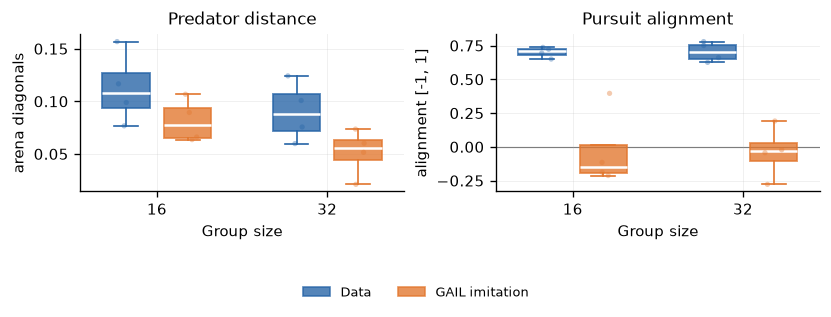

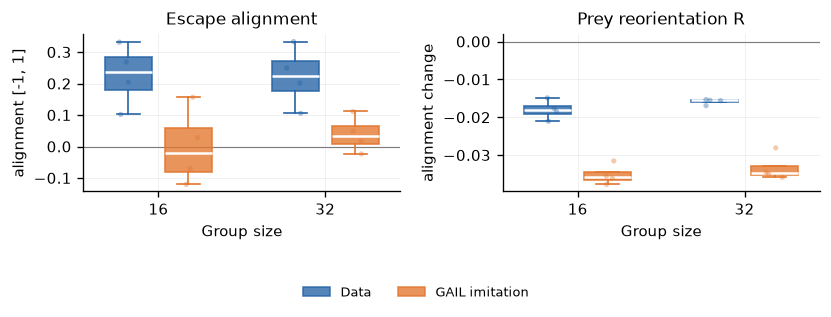

**Couzin expert DoS/DoA for the diagnostic evaluation trajectories.**

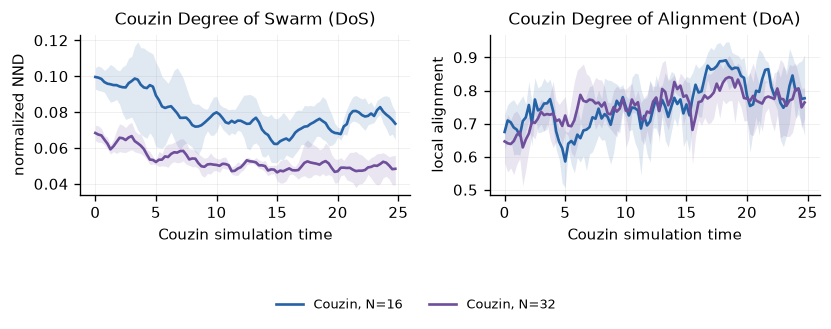

In [6]:
repair_datasets = []
repair_seed = max(ROLLOUT_SEEDS) + 100_000
repair_source = replace(ct.TRAINING_MATCHED, rollout_steps=300)
for n_prey in (16, 32):
    expert = ct.generate_couzin_expert_rollouts(
        repair_source, n_prey=n_prey, n_rollouts=N_ROLLOUTS,
        rollout_seeds=(repair_seed,))
    repair_datasets.append(ct.build_supervised_transition_data(expert, n_prey=n_prey))
repair_data = ct.combine_supervised_data(repair_datasets)
repair_pair, repair_history = ct.supervised_repair(
    repair_data, optimization_steps=REPAIR_STEPS, batch_size=2048,
    learning_rate=1e-3, attack_weight=4.0, seed=repair_seed + 10_000)
display(repair_history)
repair_spec = replace(
    ct.TRAINING_MATCHED, name='attack_weighted_bc_diagnostic',
    label='Attack-weighted BC repair diagnostic', deterministic_policy=True,
    explanation='Schema-consistent, attack-weighted supervised repair; not pure GAIL.')
repair_result = ct.evaluate_variant(
    repair_spec, rollout_seeds=(repair_seed + 20_000,),
    n_rollouts_per_seed=N_ROLLOUTS, policy_pair=repair_pair)
repair_details = pd.DataFrame(ct.result_rows(repair_result))
display(repair_details[['n_prey', 'metric_label', 'expert_mean', 'imitation_mean',
                        'absolute_gap', 'iqr_overlap']].round(4))
for category in ('Predator', 'Prey'):
    fig = ct.plot_behavior_boxplots(repair_result, category)
    display(fig); plt.close(fig)
display(Markdown('**Couzin expert DoS/DoA for the diagnostic evaluation trajectories.**'))
fig = ct.plot_expert_collective_timelines(repair_result)
display(fig); plt.close(fig)
if SAVE_ARTIFACTS:
    ct.save_variant_artifacts(repair_result, OUTPUT_DIR)

## Analysis 5 — Large independent Approach/Attack cohort

This is the primary event-based evaluation. Independent 300-step Couzin trajectories are generated for `N=16` and `N=32`, and events are detected with the same threshold, closing trend, target-persistence, minimum-duration, hysteresis, and cooldown logic used by the metric pipeline. A 50-step burn-in removes initialization transients. At most the first eligible event from each source rollout is retained, so no source trajectory can dominate the statistics.

Couzin Expert and GAIL start from the exact same event state. One common maximum-horizon realization is then truncated to 20, 40, and 80 recorded simulation states; the horizon comparison is therefore paired and cannot be explained by changing event composition. The default target is 40 unique source rollouts per group size (minimum 30, if enough valid events exist).

**What drives the results:** variability here comes from independently seeded Couzin initializations and the stochastic GAIL policy, not from added movement noise. The 20-step view measures immediate approach/attack behavior before rollout drift accumulates; 40 and 80 steps test whether any short-horizon agreement persists. For every horizon, the expert-only DoS/DoA plot directly shows the collective distribution of the Couzin windows used in that comparison.

### Cohort construction audit

,n_prey,target_windows,minimum_windows,selected_windows,source_rollouts_attempted,source_rollouts_with_valid_event,acceptance_rate,minimum_reached,unique_source_rollouts,mean_onset_distance
0,16,40,30,40,70,43,0.5714,True,40,0.1012
1,32,40,30,40,70,40,0.5714,True,40,0.0974


### Paired 20/40/80-step horizon comparison

,variant,variant_label,mean_scaled_gap,mean_gap_passes,iqr_overlaps,comparisons
0,large_independent_approach_20,"Large independent approach cohort, 20 steps",0.1126,8,12,12
1,large_independent_approach_40,"Large independent approach cohort, 40 steps",0.1614,7,7,12
2,large_independent_approach_80,"Large independent approach cohort, 80 steps",0.2016,5,4,12


### 20-step large cohort

This is the primary immediate-response estimate: rollout drift has had the least time to accumulate.

,n_prey,metric_label,expert_n,expert_mean,expert_q25,expert_q75,imitation_n,imitation_mean,imitation_q25,imitation_q75,mean_gap,absolute_gap,iqr_overlap
0,16,Normalized predator distance,40,0.0996,0.0773,0.1237,40,0.1019,0.0748,0.1223,0.0024,0.0024,0.0450
1,16,Pursuit alignment,40,0.5969,0.3583,0.8803,40,0.3139,0.1450,0.4609,-0.2830,0.2830,0.1026
2,16,Escape alignment,40,0.2231,0.1053,0.4055,40,0.1086,-0.0281,0.2572,-0.1145,0.1145,0.1519
3,16,Prey reorientation R,40,-0.0261,-0.0407,-0.0087,40,-0.0440,-0.0550,-0.0290,-0.0179,0.0179,0.0118
4,16,Degree of Swarm (DoS),40,0.0665,0.0606,0.0756,40,0.0738,0.0659,0.0832,0.0073,0.0073,0.0097
5,16,Degree of Alignment (DoA),40,0.7840,0.7647,0.8212,40,0.7828,0.7369,0.8285,-0.0012,0.0012,0.0566
6,32,Normalized predator distance,40,0.0921,0.0680,0.1090,40,0.0914,0.0702,0.1023,-0.0006,0.0006,0.0321
7,32,Pursuit alignment,40,0.6306,0.4006,0.8598,40,0.2750,0.1832,0.4294,-0.3556,0.3556,0.0288
8,32,Escape alignment,40,0.2593,0.1235,0.4303,40,0.1539,-0.0020,0.3182,-0.1054,0.1054,0.1947
9,32,Prey reorientation R,40,-0.0328,-0.0485,-0.0226,40,-0.0489,-0.0622,-0.0333,-0.0161,0.0161,0.0152


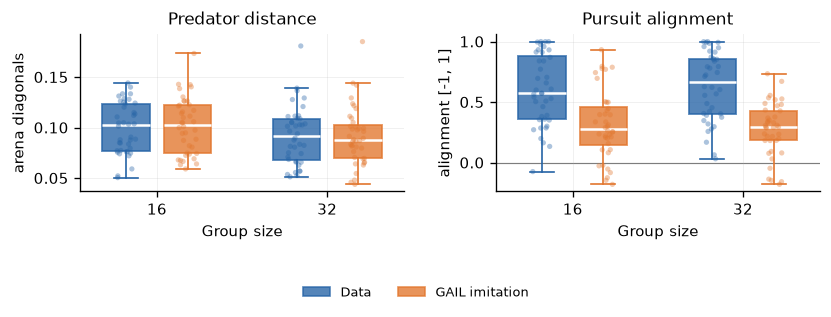

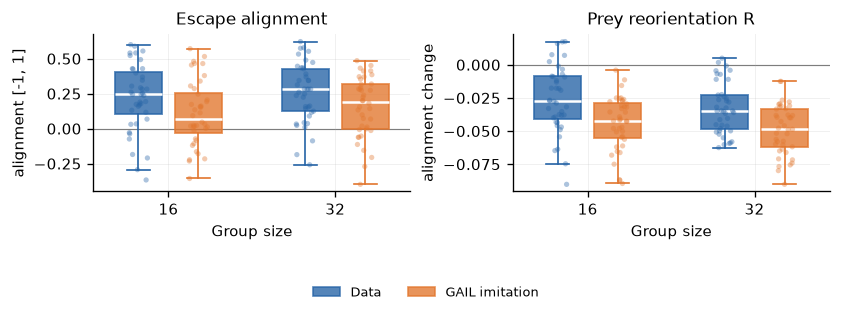

**Couzin expert DoS/DoA for the exact approach windows used above.**

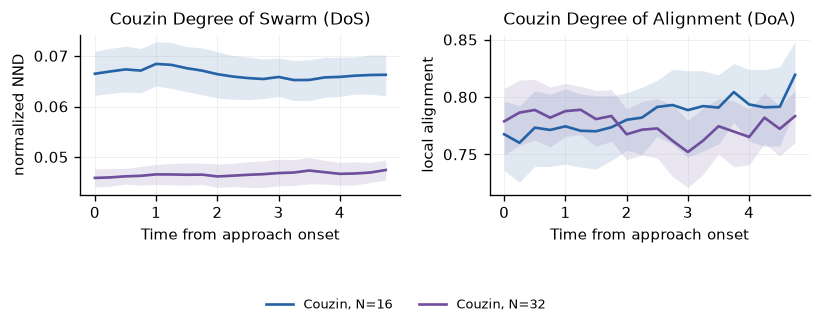

### 40-step large cohort

This longer horizon uses exactly the same events; changes therefore reflect accumulated model dynamics, not a different sample.

,n_prey,metric_label,expert_n,expert_mean,expert_q25,expert_q75,imitation_n,imitation_mean,imitation_q25,imitation_q75,mean_gap,absolute_gap,iqr_overlap
12,16,Normalized predator distance,40,0.1113,0.0867,0.1347,40,0.1069,0.0897,0.1181,-0.0044,0.0044,0.0284
13,16,Pursuit alignment,40,0.6739,0.5674,0.8006,40,0.2144,0.0482,0.3968,-0.4595,0.4595,0.0000
14,16,Escape alignment,40,0.3079,0.1683,0.4456,40,0.1501,0.0209,0.2908,-0.1577,0.1577,0.1224
15,16,Prey reorientation R,40,-0.0199,-0.0259,-0.0093,40,-0.0371,-0.0416,-0.0328,-0.0172,0.0172,0.0000
16,16,Degree of Swarm (DoS),40,0.0670,0.0618,0.0720,40,0.0794,0.0711,0.0858,0.0124,0.0124,0.0009
17,16,Degree of Alignment (DoA),40,0.8056,0.7836,0.8334,40,0.7941,0.7511,0.8220,-0.0115,0.0115,0.0383
18,32,Normalized predator distance,40,0.0926,0.0777,0.1037,40,0.0845,0.0614,0.0977,-0.0080,0.0080,0.0200
19,32,Pursuit alignment,40,0.6740,0.5657,0.7779,40,0.1610,0.0221,0.3567,-0.5129,0.5129,0.0000
20,32,Escape alignment,40,0.2694,0.1713,0.3606,40,0.1425,0.0627,0.2834,-0.1268,0.1268,0.1121
21,32,Prey reorientation R,40,-0.0235,-0.0303,-0.0188,40,-0.0396,-0.0449,-0.0326,-0.0161,0.0161,0.0000


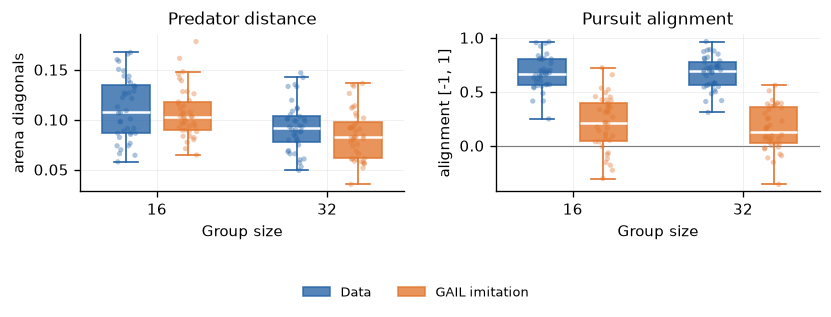

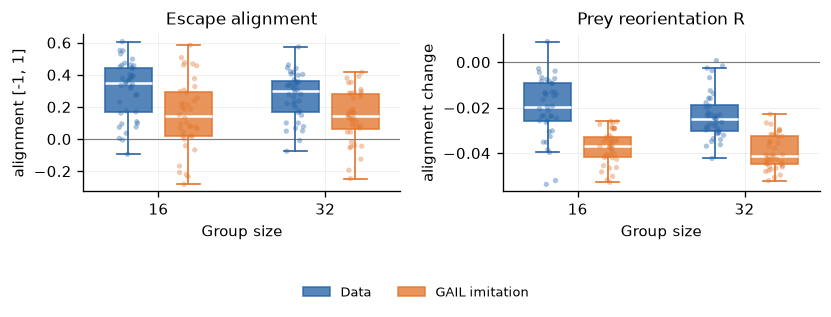

**Couzin expert DoS/DoA for the exact approach windows used above.**

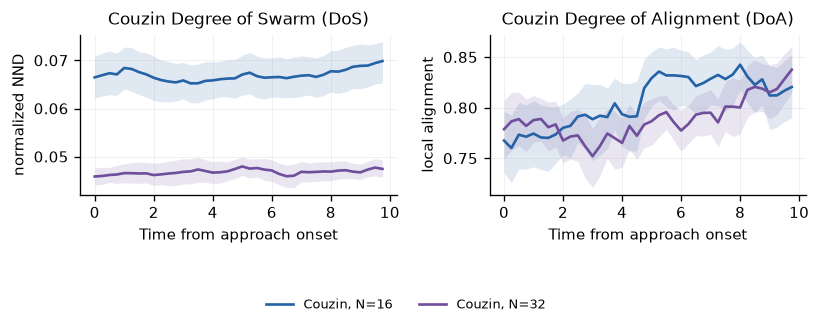

### 80-step large cohort

This longer horizon uses exactly the same events; changes therefore reflect accumulated model dynamics, not a different sample.

,n_prey,metric_label,expert_n,expert_mean,expert_q25,expert_q75,imitation_n,imitation_mean,imitation_q25,imitation_q75,mean_gap,absolute_gap,iqr_overlap
24,16,Normalized predator distance,40,0.1093,0.0823,0.1245,40,0.1162,0.0970,0.1313,0.0070,0.0070,0.0275
25,16,Pursuit alignment,40,0.6796,0.6019,0.7934,40,0.0346,-0.1005,0.1778,-0.6450,0.6450,0.0000
26,16,Escape alignment,40,0.3014,0.2136,0.3780,40,0.0680,0.0027,0.1269,-0.2335,0.2335,0.0000
27,16,Prey reorientation R,40,-0.0229,-0.0281,-0.0170,40,-0.0380,-0.0407,-0.0356,-0.0150,0.0150,0.0000
28,16,Degree of Swarm (DoS),40,0.0683,0.0630,0.0744,40,0.0843,0.0788,0.0883,0.0160,0.0160,0.0000
29,16,Degree of Alignment (DoA),40,0.8039,0.7901,0.8250,40,0.7660,0.7346,0.8049,-0.0379,0.0379,0.0149
30,32,Normalized predator distance,40,0.0873,0.0752,0.1044,40,0.0850,0.0700,0.0986,-0.0022,0.0022,0.0234
31,32,Pursuit alignment,40,0.7152,0.6463,0.7956,40,0.0756,-0.0544,0.2312,-0.6396,0.6396,0.0000
32,32,Escape alignment,40,0.2677,0.2056,0.3538,40,0.0767,-0.0048,0.1535,-0.1909,0.1909,0.0000
33,32,Prey reorientation R,40,-0.0242,-0.0294,-0.0197,40,-0.0397,-0.0429,-0.0361,-0.0155,0.0155,0.0000


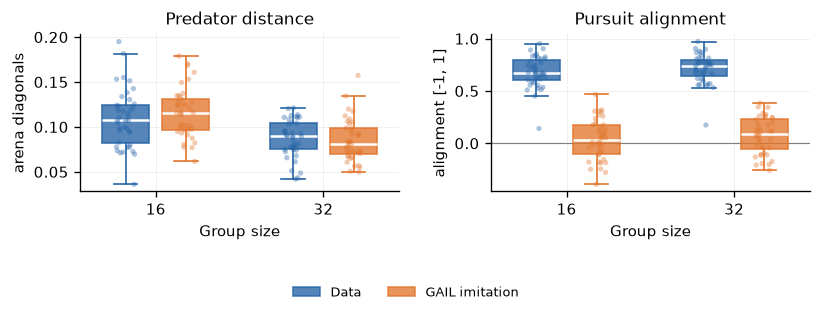

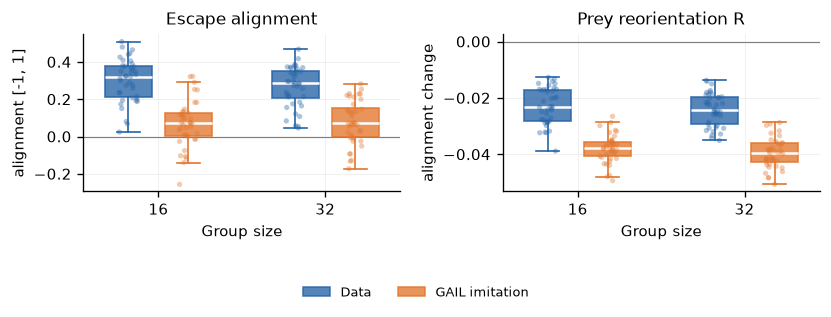

**Couzin expert DoS/DoA for the exact approach windows used above.**

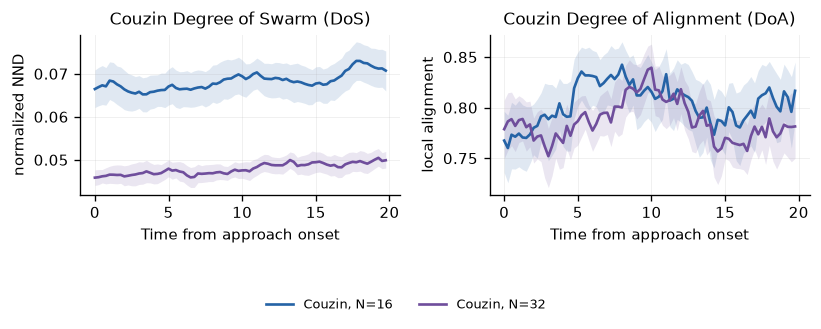

In [7]:
large_approach_results, large_approach_audit = ct.evaluate_large_approach_cohort(
    ct.TRAINING_MATCHED, horizons=(20, 40, 80),
    target_windows=LARGE_APPROACH_TARGET, minimum_windows=LARGE_APPROACH_MIN,
    max_source_rollouts=LARGE_APPROACH_MAX_ROLLOUTS,
    batch_size=LARGE_APPROACH_BATCH, source_steps=300, burn_in_steps=50,
    base_seed=min(ROLLOUT_SEEDS) + 300_000)
display(Markdown('### Cohort construction audit'))
display(large_approach_audit.round(4))
if not large_approach_audit['minimum_reached'].all():
    display(Markdown('**Sampling warning:** at least one group did not reach the requested minimum before the source-rollout cap. Results remain visible but should be interpreted as underpowered.'))
large_approach_rows = []
for horizon, result in large_approach_results.items():
    large_approach_rows.extend(ct.result_rows(result))
large_approach_details = pd.DataFrame(large_approach_rows)
large_checked = ct.quality_gate(large_approach_details)
large_horizon_summary = (large_checked.groupby(['variant', 'variant_label'], as_index=False)
    .agg(mean_scaled_gap=('scaled_absolute_gap', 'mean'),
         mean_gap_passes=('mean_gap_pass', 'sum'),
         iqr_overlaps=('iqr_overlap_pass', 'sum'),
         comparisons=('metric', 'size'))
    .sort_values('mean_scaled_gap', ignore_index=True))
display(Markdown('### Paired 20/40/80-step horizon comparison'))
display(large_horizon_summary.round(4))
for horizon, result in large_approach_results.items():
    display(Markdown(
        f'### {horizon}-step large cohort\n\n'
        + ('This is the primary immediate-response estimate: rollout drift has had the least time to accumulate.'
           if horizon == 20 else
           'This longer horizon uses exactly the same events; changes therefore reflect accumulated model dynamics, not a different sample.')))
    horizon_rows = large_approach_details.loc[large_approach_details.variant == result['spec'].name]
    display(horizon_rows[['n_prey', 'metric_label', 'expert_n', 'expert_mean',
                          'expert_q25', 'expert_q75', 'imitation_n',
                          'imitation_mean', 'imitation_q25', 'imitation_q75',
                          'mean_gap', 'absolute_gap', 'iqr_overlap']].round(4))
    for category in ('Predator', 'Prey'):
        fig = ct.plot_behavior_boxplots(result, category)
        display(fig); plt.close(fig)
    display(Markdown('**Couzin expert DoS/DoA for the exact approach windows used above.**'))
    fig = ct.plot_expert_collective_timelines(result)
    display(fig); plt.close(fig)
    if SAVE_ARTIFACTS:
        ct.save_variant_artifacts(result, OUTPUT_DIR)

## Final Couzin-only comparison and decision gate

All conditions are ranked below, but a lower aggregate score is not sufficient by itself. Each group-size/metric comparison must also pass its predeclared mean-gap tolerance, and IQR overlap is shown only as a descriptive criterion. If pursuit or escape remains outside tolerance, the notebook concludes that a schema-corrected GAIL retraining is required rather than increasing noise until the plots overlap.

In [8]:
all_details = pd.concat([screen_details, noise_details, approach_details, repair_details,
                         large_approach_details],
                        ignore_index=True).drop_duplicates(
                            subset=['variant', 'n_prey', 'metric'], keep='last')
checked = ct.quality_gate(all_details)
final_ranking = checked.groupby(['variant', 'variant_label'], as_index=False).agg(
    mean_scaled_gap=('scaled_absolute_gap', 'mean'),
    mean_gap_passes=('mean_gap_pass', 'sum'),
    iqr_overlaps=('iqr_overlap_pass', 'sum'),
    comparisons=('metric', 'size'))
final_ranking['all_mean_gaps_pass'] = (
    final_ranking.mean_gap_passes == final_ranking.comparisons)
final_ranking = final_ranking.sort_values(
    ['all_mean_gaps_pass', 'mean_scaled_gap'], ascending=[False, True], ignore_index=True)
display(final_ranking)
display(checked[['variant_label', 'n_prey', 'metric_label', 'absolute_gap',
                 'tolerance', 'mean_gap_pass', 'iqr_overlap_pass']])
if SAVE_ARTIFACTS:
    all_details.to_csv(OUTPUT_DIR / 'all_couzin_variant_metrics.csv', index=False)
    final_ranking.to_csv(OUTPUT_DIR / 'couzin_variant_ranking.csv', index=False)
if final_ranking.all_mean_gaps_pass.any():
    display(Markdown('**Decision:** At least one declared condition passes every mean-gap tolerance.'))
else:
    display(Markdown('**Decision:** No declared evaluation or noise condition passes all behavioral tolerances. '                     'The defensible next step is a complete schema-corrected, attack-balanced GAIL retraining; '                     'the biological pipeline remains untouched.'))
display(Markdown(f'Couzin-only artifacts: `{OUTPUT_DIR}`' if SAVE_ARTIFACTS
                 else 'All Couzin-only results are embedded in this notebook; artifact export is disabled.'))

,variant,variant_label,mean_scaled_gap,mean_gap_passes,iqr_overlaps,comparisons,all_mean_gaps_pass
0,large_independent_approach_20,"Large independent approach cohort, 20 steps",0.112614,8,12,12,False
1,training_matched_approach_20,"Training-matched evaluation, 20-step approaches",0.151198,7,5,12,False
2,large_independent_approach_40,"Large independent approach cohort, 40 steps",0.161449,7,7,12,False
3,large_independent_approach_80,"Large independent approach cohort, 80 steps",0.201595,5,4,12,False
4,training_matched_approach_40,"Training-matched evaluation, 40-step approaches",0.203403,8,4,12,False
5,training_matched,Training-matched evaluation,0.208653,5,2,12,False
6,training_matched_deterministic,"Training-matched, deterministic",0.210432,6,2,12,False
7,training_matched_approach_80,"Training-matched evaluation, 80-step approaches",0.211209,4,2,12,False
8,joint_last,Joint final-generation pair,0.218487,5,2,12,False
9,heading_schema_diagnostic,Heading-feature diagnostic,0.219229,5,2,12,False


,variant_label,n_prey,metric_label,absolute_gap,tolerance,mean_gap_pass,iqr_overlap_pass
0,Current paper baseline,16,Normalized predator distance,0.055474,0.015,False,False
1,Current paper baseline,16,Pursuit alignment,0.827909,0.150,False,False
2,Current paper baseline,16,Escape alignment,0.332229,0.150,False,False
3,Current paper baseline,16,Prey reorientation R,0.028255,0.015,False,False
4,Current paper baseline,16,Degree of Swarm (DoS),0.037123,0.015,False,False
...,...,...,...,...,...,...,...
187,"Large independent approach cohort, 80 steps",32,Pursuit alignment,0.639624,0.150,False,False
188,"Large independent approach cohort, 80 steps",32,Escape alignment,0.190931,0.150,False,False
189,"Large independent approach cohort, 80 steps",32,Prey reorientation R,0.015459,0.015,False,False
190,"Large independent approach cohort, 80 steps",32,Degree of Swarm (DoS),0.009953,0.015,True,False


**Decision:** No declared evaluation or noise condition passes all behavioral tolerances. The defensible next step is a complete schema-corrected, attack-balanced GAIL retraining; the biological pipeline remains untouched.

All Couzin-only results are embedded in this notebook; artifact export is disabled.